# Exercise 1 — kNN Classifier from Scratch with p-Norms

**Goal:** Code the k-Nearest Neighbors algorithm from scratch (no built-in classifiers), supporting different p-norms. Illustrate on simulated data with feature dimensions p = 10, 50, 1000, and discuss the effects of dimension and sample size on runtime.

## Solution Steps

### Step 1 — Imports & Setup
Import `numpy`, `time`, and `matplotlib`. Set a random seed for reproducibility.

### Step 2 — Implement the p-Norm Distance Function
Write a function that computes the p-norm distance between two vectors:
$$\|x - z\|_p = \left(\sum_{i=1}^{K} |x_i - z_i|^p\right)^{1/p}$$
Handle the special case $p = \infty$ (`max` of absolute values).

### Step 3 — Implement the kNN Classifier from Scratch
- For a given test point $x$, compute the p-norm distance to every training point $X_i$.
- Sort distances and pick the $k$ smallest (the k nearest neighbors).
- Assign the label by **majority vote** among those $k$ neighbors.

### Step 4 — Simulate Training & Test Data
- Create a 2-class classification problem (e.g., samples drawn from different multivariate Gaussians).
- Generate training and test samples for **three feature dimensions: $p = 10, 50, 1000$**.

### Step 5 — Evaluate Classification Accuracy
- For each dimension, run kNN on repeated test samples.
- Compute accuracy = proportion of correct classifications.
- Try different values of $k$ (e.g., $k = 1, 5, \lfloor\sqrt{n}\rfloor$).

### Step 6 — Compare Different p-Norms
- Run the classifier with at least 2–3 norms (e.g., $p = 1, 2, \infty$).
- Compare how the choice of norm affects accuracy, especially in high dimensions.

### Step 7 — Measure & Discuss Runtime
- Time the classifier for each dimension ($p = 10, 50, 1000$) and for varying training sample sizes.
- Plot runtime vs. dimension and runtime vs. sample size.
- **Discuss:** runtime grows with both dimension and sample size, since each prediction requires computing distances to all $n$ training points in $p$-dimensional space.

### Step 1 — Imports & Setup

In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

np.random.seed(42)

### Step 2 — Implement the p-Norm Distance Function

In [2]:
def p_norm_distance(x, z, p):
    """Compute the p-norm distance between vectors x and z.
    p can be any value >= 1, or np.inf for the infinity norm.
    """
    diff = np.abs(x - z)
    if p == np.inf:
        return np.max(diff, axis=-1)
    return np.sum(diff ** p, axis=-1) ** (1 / p)

### Step 3 — Implement the kNN Classifier from Scratch

In [3]:
def knn_classify(X_train, y_train, X_test, k, p=2):
    """k-Nearest Neighbors classifier from scratch.

    Parameters:
        X_train: (n, d) array of training features
        y_train: (n,) array of training labels
        X_test:  (m, d) array of test features
        k:       number of neighbors
        p:       norm to use for distance (default: 2, Euclidean)

    Returns:
        predictions: (m,) array of predicted labels
    """
    #Create an empty array with one slot per test point
    predictions = np.empty(X_test.shape[0], dtype=y_train.dtype)

    for i, x in enumerate(X_test):
        # Compute distance from x to every training point (vectorized not function call per training data
        distances = p_norm_distance(X_train - x, np.zeros_like(x), p)
        # Indices of the k nearest neighbors
        k_nearest = np.argsort(distances)[:k]
        # Majority vote
        labels, counts = np.unique(y_train[k_nearest], return_counts=True) #returns 2 tuples, one with classes and one with its count
        predictions[i] = labels[np.argmax(counts)] #returns the index of the largest count (-1,1)

    return predictions

### Step 4 — Simulate Training & Test Data

In [4]:
def simulate_data(n_train, n_test, dim):
    """
    n_train: the total number of training points to generate
    n_test: the total number of test points to generate

    Simulate a 2-class classification dataset.

    Class -1: X ~ N(0, I_dim): centered at the orign
    Class +1: X ~ N(mu, I_dim) where mu = (0.5, 0.5, ..., 0.5): centered at mu

    Returns:
        X_train, y_train, X_test, y_test
    """
    mu = np.full(dim, 0.5)

    # Training data
    n1 = n_train // 2 # half for class -1
    n2 = n_train - n1 # other half for class +1
    X_train = np.vstack([
        np.random.randn(n1, dim),          # class -1
        np.random.randn(n2, dim) + mu      # class +1
    ])
    y_train = np.array([-1]*n1 + [1]*n2)

    # Test data
    m1 = n_test // 2
    m2 = n_test - m1
    X_test = np.vstack([
        np.random.randn(m1, dim),
        np.random.randn(m2, dim) + mu
    ])
    y_test = np.array([-1]*m1 + [1]*m2)

    return X_train, y_train, X_test, y_test

# Quick test
dims = [10, 50, 1000]
for d in dims:
    X_tr, y_tr, X_te, y_te = simulate_data(200, 50, d)
    print(f"dim={d}: X_train {X_tr.shape}, X_test {X_te.shape}")

dim=10: X_train (200, 10), X_test (50, 10)
dim=50: X_train (200, 50), X_test (50, 50)
dim=1000: X_train (200, 1000), X_test (50, 1000)


### Step 5 — Evaluate Classification Accuracy

In [5]:
# Using k = 1, 5, floor(sqrt(n)) and p-norm = 2 (Euclidean)

n_train = 200
n_test = 100
n_repeats = 10  # repeated test samples to estimate accuracy

for dim in [10, 50, 1000]:
    print(f"\n=== Dimension p = {dim} ===")
    k_values = [1, 5, int(np.floor(np.sqrt(n_train)))]

    for k in k_values:
        accuracies = []
        for _ in range(n_repeats):
            X_tr, y_tr, X_te, y_te = simulate_data(n_train, n_test, dim)
            preds = knn_classify(X_tr, y_tr, X_te, k, p=2)
            acc = np.mean(preds == y_te)
            accuracies.append(acc)
        print(f"  k={k:>3d}  |  Mean accuracy: {np.mean(accuracies):.3f}  (std: {np.std(accuracies):.3f})")
        # add a rema


=== Dimension p = 10 ===
  k=  1  |  Mean accuracy: 0.641  (std: 0.062)
  k=  5  |  Mean accuracy: 0.705  (std: 0.046)
  k= 14  |  Mean accuracy: 0.738  (std: 0.041)

=== Dimension p = 50 ===
  k=  1  |  Mean accuracy: 0.828  (std: 0.035)
  k=  5  |  Mean accuracy: 0.900  (std: 0.020)
  k= 14  |  Mean accuracy: 0.916  (std: 0.023)

=== Dimension p = 1000 ===
  k=  1  |  Mean accuracy: 1.000  (std: 0.000)
  k=  5  |  Mean accuracy: 1.000  (std: 0.000)
  k= 14  |  Mean accuracy: 1.000  (std: 0.000)


### Step 6 — Compare Different p-Norms

In [6]:
# Step 6 — Compare different p-norms
# Fix k = 5, compare p = 1, 2, infinity across dimensions

k = 5
norms = [1, 2, np.inf]
norm_labels = ['p=1', 'p=2', 'p=∞']

for dim in [10, 50, 1000]:
    print(f"\n=== Dimension = {dim} ===")
    for p_norm, label in zip(norms, norm_labels):
        accuracies = []
        for _ in range(n_repeats):
            X_tr, y_tr, X_te, y_te = simulate_data(n_train, n_test, dim)
            preds = knn_classify(X_tr, y_tr, X_te, k, p=p_norm)
            acc = np.mean(preds == y_te)
            accuracies.append(acc)
        print(f"  {label:>4s}  |  Mean accuracy: {np.mean(accuracies):.3f}  (std: {np.std(accuracies):.3f})")


=== Dimension = 10 ===
   p=1  |  Mean accuracy: 0.710  (std: 0.043)
   p=2  |  Mean accuracy: 0.726  (std: 0.045)
   p=∞  |  Mean accuracy: 0.712  (std: 0.037)

=== Dimension = 50 ===
   p=1  |  Mean accuracy: 0.891  (std: 0.019)
   p=2  |  Mean accuracy: 0.911  (std: 0.019)
   p=∞  |  Mean accuracy: 0.831  (std: 0.033)

=== Dimension = 1000 ===
   p=1  |  Mean accuracy: 1.000  (std: 0.000)
   p=2  |  Mean accuracy: 1.000  (std: 0.000)
   p=∞  |  Mean accuracy: 0.977  (std: 0.017)


##### Realistically, increasing dimensions would reduce the accuracy because of the curse of dimensioanlity. Further details can be found at the end of the file.

### Step 7 — Measure & Discuss Runtime

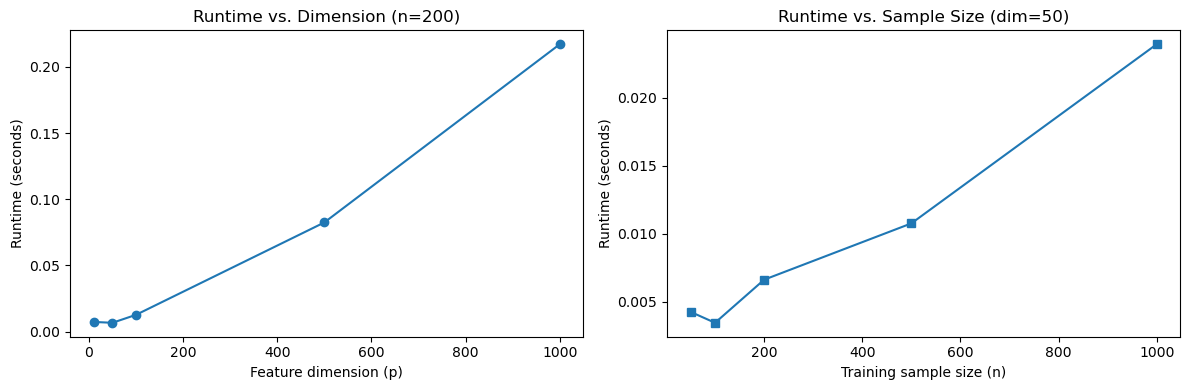


Discussion:
Runtime increases with both dimension and sample size.
Each prediction requires computing distances to all n training points,
and each distance computation scales linearly with p (the feature dimension).
This makes kNN computationally expensive in high-dimensional settings.


In [7]:
k = 5

# 7a) Runtime vs. dimension (fixed n_train=200)
dims = [10, 50, 100, 500, 1000]
times_dim = []

for dim in dims:
    X_tr, y_tr, X_te, y_te = simulate_data(200, 50, dim)
    start = time.time()
    knn_classify(X_tr, y_tr, X_te, k, p=2)
    times_dim.append(time.time() - start)

# 7b) Runtime vs. sample size (fixed dim=50)
sample_sizes = [50, 100, 200, 500, 1000]
times_n = []

for n in sample_sizes:
    X_tr, y_tr, X_te, y_te = simulate_data(n, 50, 50)
    start = time.time()
    knn_classify(X_tr, y_tr, X_te, k, p=2)
    times_n.append(time.time() - start)

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(dims, times_dim, 'o-')
axes[0].set_xlabel('Feature dimension (p)')
axes[0].set_ylabel('Runtime (seconds)')
axes[0].set_title('Runtime vs. Dimension (n=200)')

axes[1].plot(sample_sizes, times_n, 's-')
axes[1].set_xlabel('Training sample size (n)')
axes[1].set_ylabel('Runtime (seconds)')
axes[1].set_title('Runtime vs. Sample Size (dim=50)')

plt.tight_layout()
plt.show()

print("\nDiscussion:")
print("Runtime increases with both dimension and sample size.")
print("Each prediction requires computing distances to all n training points,")
print("and each distance computation scales linearly with p (the feature dimension).")
print("This makes kNN computationally expensive in high-dimensional settings.")

For very small dimensions the runtime measurements exhibit minor fluctuations. This is due to measurement noise and system overhead, which can dominate the execution time when the computational workload is extremely small. As the dimensionality increases, the expected trend becomes clear and the runtime grows approximately linearly with the number of features, consistent with the 𝑂(𝑛𝑑) complexity of the kNN distance computation.

## Curse of dimensionality

In our simulation study we consider a high-dimensional binary classification problem in which only a small subset of the variables carries useful information about the class label. Specifically, observations belong to one of two classes generated from multivariate Gaussian distributions:

$$
X \mid Y = 0 \sim \mathcal{N}(\mu_0, I_d), \qquad
X \mid Y = 1 \sim \mathcal{N}(\mu_1, I_d)
$$

where $d$ denotes the total number of features and $I_d$ is the $d \times d$ identity covariance matrix.
The mean vectors are defined as

$$
\mu_0 = (0,0,\dots,0)
$$

$$
\mu_1 = (\text{signal},\dots,\text{signal},0,\dots,0)
$$

so that only the first 𝑠 coordinates differ between the two classes. In our experiments we set 𝑠=10. These coordinates are referred to as informative dimensions, because they contain the signal that separates the classes. The remaining 𝑑−𝑠 variables have identical distributions in both classes and therefore represent pure noise.

This setup allows us to study the behavior of classification methods when the number of irrelevant features increases. In particular, while the informative signal remains fixed in the first ten dimensions, the total dimensionality $d$ is varied (e.g., $d = 10, 50, 1000$). As $d$ grows, the dataset contains an increasing number of noise variables that do not contribute to class separation.

This scenario is especially relevant for studying the performance of the k‑Nearest Neighbors algorithm, which relies directly on distances between observations. Because distances include contributions from all coordinates, the presence of many non-informative features can distort the notion of similarity between points. Consequently, even though the true signal remains confined to ten dimensions, increasing the overall dimensionality can degrade classification performance. This phenomenon is related to the Curse of Dimensionality, where distances in high-dimensional spaces become dominated by noise rather than informative structure.

The simulation framework therefore provides a controlled environment for evaluating how kNN behaves as dimensionality increases and for assessing whether dimensionality-reduction techniques such as random projections can mitigate the negative effects of high dimensionality.

In [8]:
import numpy as np
import time
from collections import Counter
import matplotlib.pyplot as plt


# 1. Minkowski distance from scratch
def minkowski_distance(x, y, p=2):
    """
    Compute the Minkowski distance of order p between two 1D numpy arrays.
    """
    if len(x) != len(y):
        raise ValueError("x and y must have the same length.")
    return np.sum(np.abs(x - y) * p) * (1 / p)

# 2. Predict one observation with kNN
def knn_predict_one(x_test, X_train, y_train, k=5, p=2):
    """
    Predict the class of a single test observation x_test using kNN.
    """
    distances = np.empty(X_train.shape[0])

    for i in range(X_train.shape[0]):
        distances[i] = minkowski_distance(x_test, X_train[i], p=p)

    # indices of k nearest neighbors
    # argsort returns the index
    nn_idx = np.argsort(distances)[:k]
    nn_labels = y_train[nn_idx]

    # majority vote
    counts = Counter(nn_labels)
    # return the first element of the tuple
    # of the most frequent label
    pred = counts.most_common(1)[0][0]

    return pred

# 3. Predict a whole test set
def knn_predict(X_test, X_train, y_train, k=5, p=2):
    """
    Predict classes for all observations in X_test using kNN.
    """
    preds = np.empty(X_test.shape[0], dtype=int)

    for i in range(X_test.shape[0]):
        preds[i] = knn_predict_one(X_test[i], X_train, y_train, k=k, p=p)

    return preds

# 4. Classification accuracy
def classification_accuracy(y_true, y_pred):
    """
    Compute relative proportion of correct classifications.
    """
    return np.mean(y_true == y_pred)

# 5. Simulate binary classification data
def simulate_data(n, d, signal=1.5, informative_dims=10, seed=None):
    """
    Simulate data from two Gaussian classes.

    Class 0 ~ N(mu0, I)
    Class 1 ~ N(mu1, I)

    Only the first informative_dims coordinates differ in mean.
    """
    if seed is not None:
        np.random.seed(seed)

    # only some features are usefule
    informative_dims = min(informative_dims, d)

    y = np.random.choice([0, 1], size=n)

    mu0 = np.zeros(d)
    mu1 = np.zeros(d)
    mu1[:informative_dims] = signal

    X = np.zeros((n, d))

    for i in range(n):
        if y[i] == 0:
            X[i] = np.random.normal(loc=mu0, scale=1.0, size=d)
        else:
            X[i] = np.random.normal(loc=mu1, scale=1.0, size=d)

    return X, y

# 6. Repeated estimation of accuracy
def run_knn_experiment(
    n_train=200,
    n_test=200,
    d=10,
    k=5,
    p=2,
    signal=0.5,
    informative_dims=10,
    n_reps=50,
    seed=None
):
    """
    Simulate one training sample, then repeatedly generate test samples
    and estimate classification accuracy.
    """
    if seed is not None:
        np.random.seed(seed)

    # one fixed training sample
    X_train, y_train = simulate_data(
        n=n_train,
        d=d,
        signal=signal,
        informative_dims=informative_dims
    )

    accuracies = []

    for _ in range(n_reps):
        X_test, y_test = simulate_data(
            n=n_test,
            d=d,
            signal=signal,
            informative_dims=informative_dims
        )

        y_pred = knn_predict(X_test, X_train, y_train, k=k, p=p)
        acc = classification_accuracy(y_test, y_pred)
        accuracies.append(acc)

    accuracies = np.array(accuracies)

    return {
        "mean_accuracy": np.mean(accuracies),
        "sd_accuracy": np.std(accuracies, ddof=1),
        "accuracies": accuracies
    }

# 7. Measure runtime
def measure_runtime(
    n_train=200,
    n_test=100,
    d=10,
    k=5,
    p=2,
    signal=1.5,
    informative_dims=10
):
    """
    Measure elapsed runtime for kNN prediction on one simulated train/test pair.
    """
    X_train, y_train = simulate_data(
        n=n_train, d=d, signal=signal, informative_dims=informative_dims
    )
    X_test, y_test = simulate_data(
        n=n_test, d=d, signal=signal, informative_dims=informative_dims
    )

    start = time.time()
    _ = knn_predict(X_test, X_train, y_train, k=k, p=p)
    end = time.time()

    return end - start


# 8. Example: accuracy for d = 10, 50, 1000
def main():
    np.random.seed(123)

    dimensions = [10, 50, 1000]

    print("=== Accuracy results for p-norm order p = 2 ===")
    for d in dimensions:
        result = run_knn_experiment(
            n_train=200,
            n_test=200,
            d=d,
            k=5,
            p=2,
            signal=1.5,
            informative_dims=10,
            n_reps=30
        )

        print(f"d = {d}")
        print(f"  Mean accuracy = {result['mean_accuracy']:.4f}")
        print(f"  SD accuracy   = {result['sd_accuracy']:.4f}")
        print()

    # 9. Compare different norms
    print("=== Comparison of different norms ===")
    p_values = [1, 2, 3]

    for p_val in p_values:
        print(f"Norm order p = {p_val}")
        for d in dimensions:
            result = run_knn_experiment(
                n_train=200,
                n_test=200,
                d=d,
                k=5,
                p=p_val,
                signal=1.5,
                informative_dims=10,
                n_reps=20
            )
            print(f"  d = {d}: mean accuracy = {result['mean_accuracy']:.4f}")
        print()

In [9]:
main()

=== Accuracy results for p-norm order p = 2 ===
d = 10
  Mean accuracy = 0.9900
  SD accuracy   = 0.0069

d = 50
  Mean accuracy = 0.9688
  SD accuracy   = 0.0114

d = 1000
  Mean accuracy = 0.7415
  SD accuracy   = 0.0318

=== Comparison of different norms ===
Norm order p = 1
  d = 10: mean accuracy = 0.9865
  d = 50: mean accuracy = 0.9685
  d = 1000: mean accuracy = 0.7530

Norm order p = 2
  d = 10: mean accuracy = 0.9862
  d = 50: mean accuracy = 0.9682
  d = 1000: mean accuracy = 0.7442

Norm order p = 3
  d = 10: mean accuracy = 0.9860
  d = 50: mean accuracy = 0.9617
  d = 1000: mean accuracy = 0.7175

